In [ ]:
# 1. IMPORT LIBRARIES, CONFIGURE PATHS & LOAD DATA
# ------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras

import joblib

# Setting theme style for all figures
sns.set_theme(style="whitegrid", palette="muted")

# ARTIFACT PATH DIRECTORY SETUP
ARTIFACT_ROOT = Path("/kaggle/working/streamintel360_artifacts") / "notebook_01_churn"

MODELS_DIR = ARTIFACT_ROOT / "models"
PREPROCESSORS_DIR = ARTIFACT_ROOT / "preprocessors"
METRICS_DIR = ARTIFACT_ROOT / "metrics"
FIGURES_DIR = ARTIFACT_ROOT / "figures"
METADATA_DIR = ARTIFACT_ROOT / "metadata"

# Create directories if they do not exist
for dir_path in [MODELS_DIR, PREPROCESSORS_DIR, METRICS_DIR, FIGURES_DIR, METADATA_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

# Loading subscriber churn data
churn_df = pd.read_csv("/kaggle/input/datasets/hamaz911/subscriber-churn-data/churn_data.csv")

# StreamIntel 360: Domain Column Renaming
column_mapping = {
    "tenure": "tenure_months",
    "MonthlyCharges": "monthly_fee_usd",
    "TotalCharges": "total_spend_usd",
    "TechSupport": "streaming_support_tickets",
    "Contract": "subscription_tier",
    "Churn": "churn_label"
}
churn_df.rename(columns={k: v for k, v in column_mapping.items() if k in churn_df.columns}, inplace=True)
churn_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure_months,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,streaming_support_tickets,StreamingTV,StreamingMovies,subscription_tier,PaperlessBilling,PaymentMethod,monthly_fee_usd,total_spend_usd,churn_label
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# 2. DATA CLEANING & PREPROCESSING
# ----------------------------------

# Determining target total spend column name based on Cell 1 mapping
total_spend_col = "total_spend_usd" if "total_spend_usd" in churn_df.columns else "TotalCharges"
id_col = "user_id" if "user_id" in churn_df.columns else "customerID"

# Checking missing values
print("Missing Values: ", churn_df.isnull().sum())

# Checking data types of all columns
print("\nDataType: ")
churn_df.info()

# Checking unique values in total spend column to inspect text values
print(f"\nUnique Values in {total_spend_col}:", churn_df[total_spend_col].unique())

# Counting hidden blank spaces
print("\nHidden Blank Spaces: ")
print((churn_df == " ").sum()[(churn_df == " ").sum() > 0])

# Replacing blank spaces with NaN and converting datatype to float
churn_df[total_spend_col] = churn_df[total_spend_col].replace(" ", np.nan)
churn_df[total_spend_col] = churn_df[total_spend_col].astype(float)

# Re-checking missing values to confirm NaN conversion
print("\nMissing Values After Conversion: ", churn_df.isnull().sum())

# Dropping rows with missing values and dropping identifier column
churn_df.dropna(inplace=True)
if id_col in churn_df.columns:
    churn_df.drop(id_col, axis=1, inplace=True)

print("\nCleaned Data Shape: ", churn_df.shape)

# Categorical and Numerical columns
numerical_cols = churn_df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = churn_df.select_dtypes(include=['object']).columns
print("\nNumerical Columns:", numerical_cols.tolist())
print("\nCategorical Columns:", categorical_cols.tolist())

Missing Values:  customerID                   0
gender                       0
SeniorCitizen                0
Partner                      0
Dependents                   0
tenure_months                0
PhoneService                 0
MultipleLines                0
InternetService              0
OnlineSecurity               0
OnlineBackup                 0
DeviceProtection             0
streaming_support_tickets    0
StreamingTV                  0
StreamingMovies              0
subscription_tier            0
PaperlessBilling             0
PaymentMethod                0
monthly_fee_usd              0
total_spend_usd              0
churn_label                  0
dtype: int64

DataType: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   gender                     

Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_01_churn/figures/figure1_churn_distribution.png


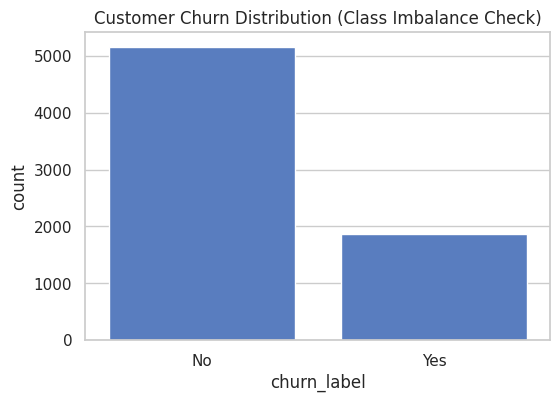

Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_01_churn/figures/figure2_monthly_charges_dist.png


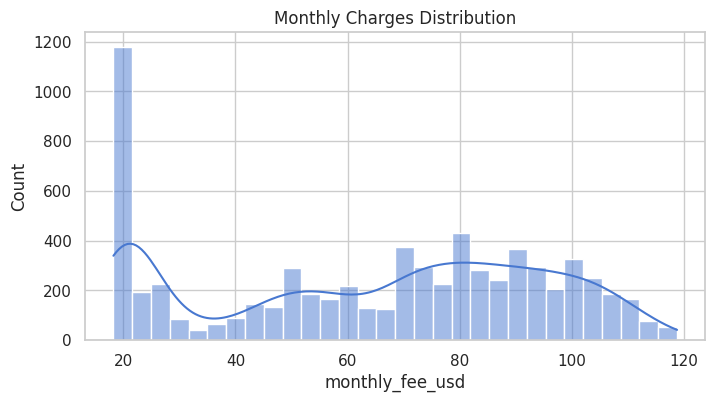

Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_01_churn/figures/figure3_tenure_vs_churn.png


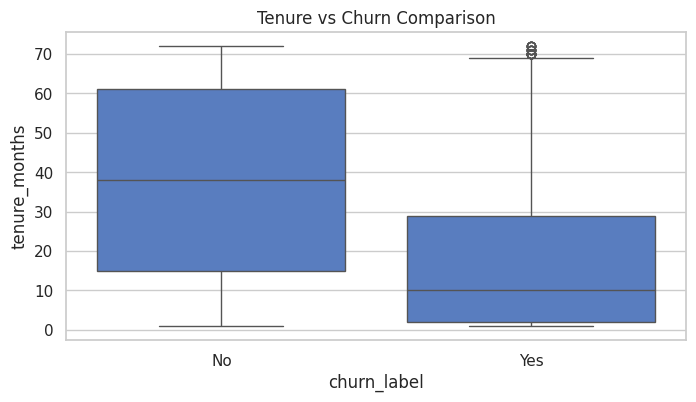

Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_01_churn/figures/figure4_correlation_heatmap.png


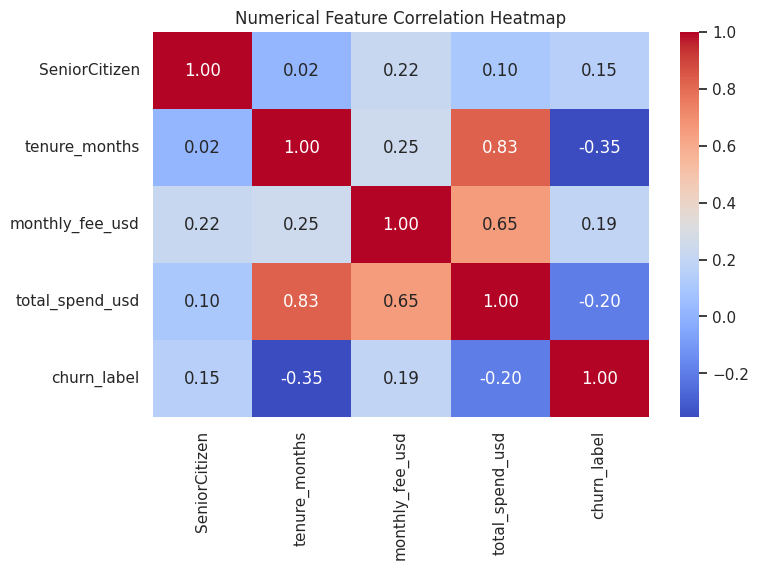

Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_01_churn/figures/figure5_churn_by_contract.png


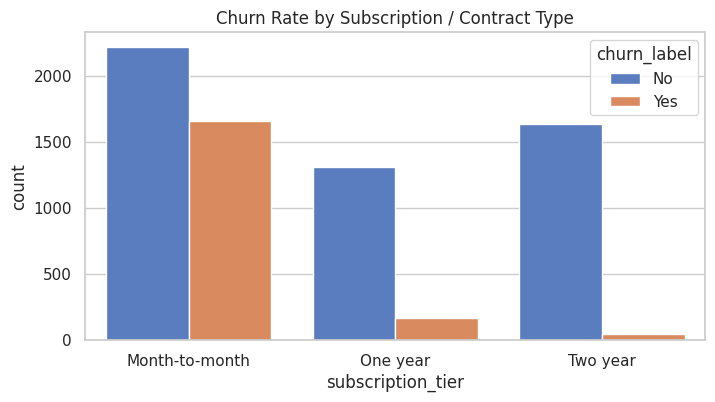

Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_01_churn/figures/figure6_churn_by_internet_service.png


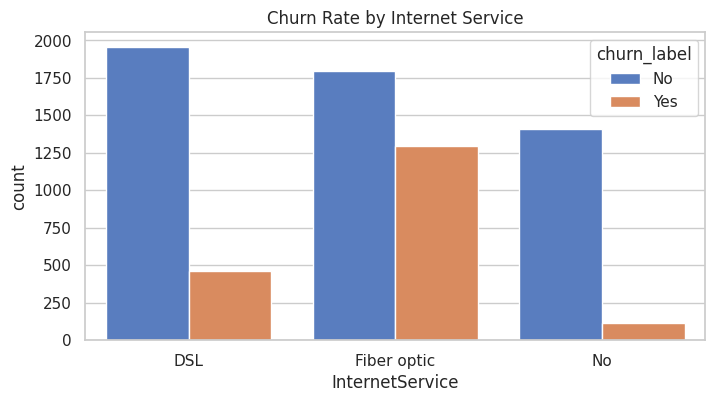

Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_01_churn/figures/figure7_churn_by_payment_method.png


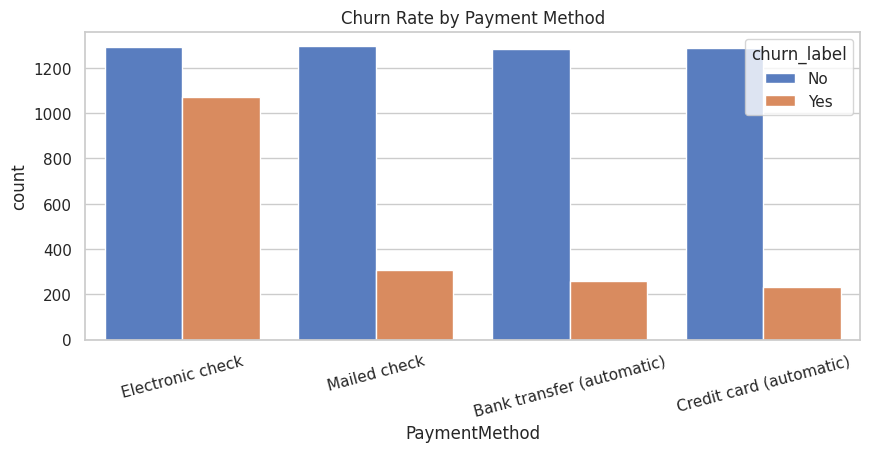

Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_01_churn/figures/figure8_churn_by_tech_support.png


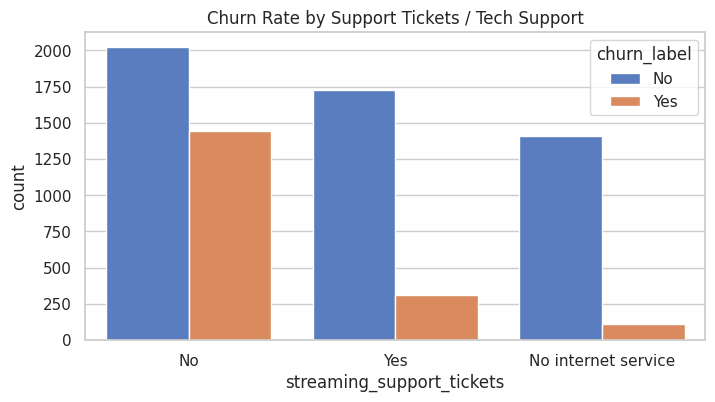

All figures exported successfully into /kaggle/working/streamintel360_artifacts/notebook_01_churn/figures


In [3]:
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ------------------------------------------

# Use the centralized FIGURES_DIR created in Cell 1
figures_dir = FIGURES_DIR

# Creating function to save figure in exact directory
def save_fig(fig_name):
    file_path = figures_dir / f"{fig_name}.png"
    plt.savefig(file_path, dpi=300, bbox_inches="tight")
    print(f"Figure Saved: {file_path}")

# Dynamic Column Selectors (Supports raw and renamed columns)
target_col = "churn_label" if "churn_label" in churn_df.columns else "Churn"
charges_col = "monthly_fee_usd" if "monthly_fee_usd" in churn_df.columns else "MonthlyCharges"
tenure_col = "tenure_months" if "tenure_months" in churn_df.columns else "tenure"
contract_col = "subscription_tier" if "subscription_tier" in churn_df.columns else "Contract"
support_col = "streaming_support_tickets" if "streaming_support_tickets" in churn_df.columns else "TechSupport"
internet_col = "InternetService" if "InternetService" in churn_df.columns else "InternetService"
payment_col = "PaymentMethod" if "PaymentMethod" in churn_df.columns else "PaymentMethod"

# Figure 1: Checking balance of target variable
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=target_col, data=churn_df)
plt.title("Customer Churn Distribution (Class Imbalance Check)")
save_fig("figure1_churn_distribution")
plt.show()

# Figure 2: Monthly Charges Distribution
plt.figure(figsize=(8, 4))
sns.histplot(churn_df[charges_col], bins=30, kde=True)
plt.title("Monthly Charges Distribution")
save_fig("figure2_monthly_charges_dist")
plt.show()

# Figure 3: Tenure vs Churn Boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=target_col, y=tenure_col, data=churn_df)
plt.title("Tenure vs Churn Comparison")
save_fig("figure3_tenure_vs_churn")
plt.show()

# Figure 4: Numerical Correlation Heatmap
df_heatmap = churn_df.copy()
if df_heatmap[target_col].dtype == object:
    df_heatmap[target_col] = (df_heatmap[target_col] == "Yes").astype(int)

plt.figure(figsize=(8, 5))
sns.heatmap(df_heatmap.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Numerical Feature Correlation Heatmap")
save_fig("figure4_correlation_heatmap")
plt.show()

# Figure 5: Churn by Contract Type
if contract_col in churn_df.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=contract_col, hue=target_col, data=churn_df)
    plt.title("Churn Rate by Subscription / Contract Type")
    save_fig("figure5_churn_by_contract")
    plt.show()

# Figure 6: Churn by Internet Service
if internet_col in churn_df.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=internet_col, hue=target_col, data=churn_df)
    plt.title("Churn Rate by Internet Service")
    save_fig("figure6_churn_by_internet_service")
    plt.show()

# Figure 7: Churn by Payment Method
if payment_col in churn_df.columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=payment_col, hue=target_col, data=churn_df)
    plt.xticks(rotation=15)
    plt.title("Churn Rate by Payment Method")
    save_fig("figure7_churn_by_payment_method")
    plt.show()

# Figure 8: Churn by Tech Support Availability
if support_col in churn_df.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=support_col, hue=target_col, data=churn_df)
    plt.title("Churn Rate by Support Tickets / Tech Support")
    save_fig("figure8_churn_by_tech_support")
    plt.show()

print(f"All figures exported successfully into {figures_dir.resolve()}")

In [4]:
# 4. FEATURE ENGINEERING & SPLITTING
# --------------------------------------

# Defining target column y
target_col = "churn_label" if "churn_label" in churn_df.columns else "Churn"

# Splitting into X
X = churn_df.drop(target_col, axis=1)

# Converting target safely 
if churn_df[target_col].dtype == object:
    y = (churn_df[target_col] == "Yes").astype(int)
else:
    y = churn_df[target_col].astype(int)

# One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# NOTE: scaler and feature columns are saved once, in the final
# artifact export step (Section 9) -- avoids writing the same
# preprocessor files to disk twice in one run.

# Creating function to evaluate models
def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }

model_results = []


Scaler saved to: /kaggle/working/streamintel360_artifacts/notebook_01_churn/preprocessors/scaler.joblib
Feature columns metadata saved to: /kaggle/working/streamintel360_artifacts/notebook_01_churn/preprocessors/feature_columns.joblib


In [5]:
# 5. BASELINE MACHINE LEARNING MODELS
# --------------------------------------------------

# Creating dict to store trained models
trained_models = {}

# Creating dict to build baseline models
BASELINE_MODELS = {
    "Logistic Regression": (LogisticRegression(random_state=42, max_iter=1000), True),
    "Decision Tree (Baseline)": (DecisionTreeClassifier(random_state=42), False),
    "Random Forest (Baseline)": (RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1), False),
    "XGBoost (Baseline)": (XGBClassifier(random_state=42, eval_metric="logloss", verbosity=0), False)
}

# Using loop to train all models
for model_name, (model, use_scaled_data) in BASELINE_MODELS.items():

    print(f"Training....... : {model_name}")
    
    # Selecting appropriate datasets for training
    X_train_model = X_train_scaled if use_scaled_data else X_train
    X_test_model = X_test_scaled if use_scaled_data else X_test

    # Training model
    model.fit(X_train_model, y_train)

    # Saving trained model in dict
    trained_models[model_name] = model

    # Predictions
    y_pred = model.predict(X_test_model)
    y_proba = model.predict_proba(X_test_model)[:, 1]

    # Evaluating and appending to results list
    model_results.append(evaluate_model(model_name, y_test, y_pred, y_proba))

    print(f"{model_name} Trained Successfully.\n")

print(f"Successfully trained all {len(BASELINE_MODELS)} baseline models.")

Training....... : Logistic Regression
Logistic Regression Trained Successfully.

Training....... : Decision Tree (Baseline)
Decision Tree (Baseline) Trained Successfully.

Training....... : Random Forest (Baseline)
Random Forest (Baseline) Trained Successfully.

Training....... : XGBoost (Baseline)
XGBoost (Baseline) Trained Successfully.

Successfully trained all 4 baseline models.


In [6]:
# 6. HYPERPARAMETER TUNING
# ----------------------------------------

# Creating dict to store tuned models
tuned_models = {}

# Random Forest - GridSearchCV
print("Tuning -------> Random Forest")

param_grid_rf = {"n_estimators": [100, 200],
                 "max_depth": [5, 10, None],
                 "min_samples_split": [2, 5],
                 "min_samples_leaf": [1, 2]}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

# Saving tuned model
tuned_models["Tuned Random Forest"] = best_rf

print(f"\nBest parameters for Random Forest: {grid_rf.best_params_}")

# Evaluating
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

# Appending results 
model_results.append(evaluate_model("Random Forest (Tuned)", y_test, y_pred, y_proba))
print("Tuning completed for Random Forest \n")

# XGBoost - RandomizedSearchCV
print("Tuning -------> XGBoost")

param_dist_xgb = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

rand_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric="logloss", verbosity=0),
    param_distributions=param_dist_xgb,
    n_iter=10,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

rand_xgb.fit(X_train, y_train)
best_xgb = rand_xgb.best_estimator_

# Saving tuned model
tuned_models["Tuned XGBoost"] = best_xgb

print(f"\nBest XGBoost Parameters: {rand_xgb.best_params_}")

# Evaluating
y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]

model_results.append(evaluate_model("XGBoost (Tuned)", y_test, y_pred, y_proba))

print("Tuning completed for XGBoost \n")

Tuning -------> Random Forest

Best parameters for Random Forest: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Tuning completed for Random Forest 

Tuning -------> XGBoost

Best XGBoost Parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Tuning completed for XGBoost 



In [7]:
# 7. ARTIFICIAL NEURAL NETWORK (ANN)
# ------------------------------------------

# Building ANN Model
ann_model = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.30),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.20),
    keras.layers.Dense(1, activation="sigmoid")
])

# Compiling Model
ann_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Callbacks using centralized MODELS_DIR from Cell 1
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=MODELS_DIR / "best_ann.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Training Model
print("Training -------> Artificial Neural Network")
history = ann_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

I0000 00:00:1786585794.880805      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13348 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786585794.883600      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Training -------> Artificial Neural Network
Epoch 1/50
 70/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6731 - loss: 0.5976

I0000 00:00:1786585800.028869    1887 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7004 - loss: 0.5662
Epoch 1: val_loss improved from None to 0.44632, saving model to /kaggle/working/streamintel360_artifacts/notebook_01_churn/models/best_ann.keras

Epoch 1: finished saving model to /kaggle/working/streamintel360_artifacts/notebook_01_churn/models/best_ann.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7364 - loss: 0.5238 - val_accuracy: 0.7787 - val_loss: 0.4463 - learning_rate: 0.0010
Epoch 2/50
122/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7524 - loss: 0.4865
Epoch 2: val_loss improved from 0.44632 to 0.41993, saving model to /kaggle/working/streamintel360_artifacts/notebook_01_churn/models/best_ann.keras

Epoch 2: finished saving model to /kaggle/working/streamintel360_artifacts/notebook_01_churn/models/best_ann.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7689 - loss: 0.4692 - val_accuracy: 0.7867 - val_loss: 0.4199 - learning_rate: 0.0010
Epoch 3/50
138/141 ━━━━━━━━━

In [8]:
# 8. COMPARISON TABLE FOR ALL MODELS
# -----------------------------------------

# Evaluating ANN on test set & append to results list
y_proba_ann = ann_model.predict(X_test_scaled).ravel()
y_pred_ann = (y_proba_ann > 0.5).astype(int)
model_results.append(evaluate_model("Artificial Neural Network (ANN)", y_test, y_pred_ann, y_proba_ann))

# Creating dataframe
comparison_df = (pd.DataFrame(model_results).sort_values(by="F1 Score", ascending=False).round(4).reset_index(drop=True))
print("Final Comparison Table for all Models:")

display(comparison_df.style.highlight_max(
        subset=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
        color="lightgreen"
    )
)

# Exporting metrices 
comparison_df.to_csv(METRICS_DIR / "model_comparison.csv", index=False)
comparison_df.to_json(METRICS_DIR / "model_comparison.json", orient="records", indent=4)

print(f"\nComparison saved successfully into {METRICS_DIR / 'model_comparison.csv'}")
print(f"JSON metrics exported successfully into {METRICS_DIR / 'model_comparison.json'}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Final Comparison Table for all Models:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803800,0.647600,0.574900,0.609100,0.835700
1,Artificial Neural Network (ANN),0.788900,0.609100,0.574900,0.591500,0.830800
2,XGBoost (Tuned),0.789600,0.623400,0.526700,0.571000,0.837500
3,XGBoost (Baseline),0.778300,0.589100,0.548100,0.567900,0.819700
4,Random Forest (Baseline),0.786800,0.620900,0.508000,0.558800,0.818100
5,Random Forest (Tuned),0.788900,0.628800,0.502700,0.558700,0.834500
6,Decision Tree (Baseline),0.718600,0.470100,0.462600,0.466300,0.636600



Comparison saved successfully into /kaggle/working/streamintel360_artifacts/notebook_01_churn/metrics/model_comparison.csv
JSON metrics exported successfully into /kaggle/working/streamintel360_artifacts/notebook_01_churn/metrics/model_comparison.json


In [9]:
# 9. SAVE BEST MODEL & PREPROCESSING ARTIFACTS
# -----------------------------------------------

import json

# Identify best performing classical ML model (filtering out ANN)
ml_comparison = comparison_df[~comparison_df["Model"].str.contains("ANN|Neural Network", na=False)]
best_model_name = ml_comparison.iloc[0]["Model"]
best_model_metrics = ml_comparison.iloc[0].to_dict()
print(f"Best ML Model Selected: {best_model_name}")

# Unified dictionary mapping exact comparison table names to trained model objects
all_models = {
    "Logistic Regression": trained_models.get("Logistic Regression"),
    "Decision Tree (Baseline)": trained_models.get("Decision Tree (Baseline)"),
    "Random Forest (Baseline)": trained_models.get("Random Forest (Baseline)"),
    "XGBoost (Baseline)": trained_models.get("XGBoost (Baseline)"),
    "Random Forest (Tuned)": tuned_models.get("Tuned Random Forest"),
    "XGBoost (Tuned)": tuned_models.get("Tuned XGBoost")
}

# Retrieving best trained model object
best_model = all_models.get(best_model_name)

if best_model is None:
    print("Exact name key not matched; defaulting to best tuned estimator.")
    best_model = best_xgb if 'best_xgb' in locals() else best_rf

# Exporting artifacts to managed directories
# Models
joblib.dump(best_model, MODELS_DIR / "best_model.joblib")

# Preprocessors
joblib.dump(scaler, PREPROCESSORS_DIR / "scaler.joblib")
joblib.dump(X_train.columns.tolist(), PREPROCESSORS_DIR / "feature_columns.joblib")

# Notebook Metadata Payload
notebook_01_metadata = {
    "notebook": "notebook_01_churn",
    "domain": "Subscriber Churn Intelligence",
    "best_classical_model": best_model_name,
    "best_classical_metrics": best_model_metrics,
    "total_train_samples": int(X_train.shape[0]),
    "total_test_samples": int(X_test.shape[0]),
    "num_features": int(X_train.shape[1]),
    "feature_names": X_train.columns.tolist(),
    "ann_checkpoint": "best_ann.keras"
}

with open(METADATA_DIR / "metadata.json", "w") as f:
    json.dump(notebook_01_metadata, f, indent=4)

print(f"\nAll artifacts exported successfully:")
print(f"--> Model: {MODELS_DIR / 'best_model.joblib'} ({best_model_name})")
print(f"--> Scaler: {PREPROCESSORS_DIR / 'scaler.joblib'}")
print(f"--> Features: {PREPROCESSORS_DIR / 'feature_columns.joblib'}")
print(f"--> Metadata: {METADATA_DIR / 'metadata.json'}")

Best ML Model Selected: Logistic Regression

All artifacts exported successfully:
--> Model: /kaggle/working/streamintel360_artifacts/notebook_01_churn/models/best_model.joblib (Logistic Regression)
--> Scaler: /kaggle/working/streamintel360_artifacts/notebook_01_churn/preprocessors/scaler.joblib
--> Features: /kaggle/working/streamintel360_artifacts/notebook_01_churn/preprocessors/feature_columns.joblib
--> Metadata: /kaggle/working/streamintel360_artifacts/notebook_01_churn/metadata/metadata.json


In [10]:
# 10. QUICK VERIFICATION
# ---------------------------------------

print("Verifying saved artifacts from managed directory structure.......")

# Loading saved artifacts from central directory paths
loaded_model = joblib.load(MODELS_DIR / "best_model.joblib")
loaded_scaler = joblib.load(PREPROCESSORS_DIR / "scaler.joblib")
loaded_features = joblib.load(PREPROCESSORS_DIR / "feature_columns.joblib")

# Preparing sample data with exact feature ordering
sample_data = X_test.iloc[[0]][loaded_features]

# Scaled sample data (required if model expects normalized inputs)
if "Logistic Regression" in best_model_name:
    sample_input = loaded_scaler.transform(sample_data)
else:
    sample_input = sample_data

# Running inference
sample_prediction = loaded_model.predict(sample_input)[0]
sample_probability = loaded_model.predict_proba(sample_input)[0][1]

print(f"Best Model        : {best_model_name}")
print(f"Feature Count     : {len(loaded_features)}")
print(f"Sample Prediction : {'Churn (1)' if sample_prediction == 1 else 'Retain (0)'}")
print(f"Churn Probability : {sample_probability:.4f} ({sample_probability * 100:.2f}%)")

Verifying saved artifacts from managed directory structure.......
Best Model        : Logistic Regression
Feature Count     : 30
Sample Prediction : Retain (0)
Churn Probability : 0.0171 (1.71%)


In [ ]:
import shutil
from pathlib import Path

artifact_root = Path("/kaggle/working/streamintel360_artifacts/notebook_01_churn")
zip_base = Path("/kaggle/working/streamintel360_notebook_01_churn")
zip_path = shutil.make_archive(str(zip_base),"zip",root_dir=artifact_root.parent,base_dir=artifact_root.name)

print("NOTEBOOK 01 BACKUP CREATED")
print(f"ZIP file : {zip_path}")
print(f"Size     : {Path(zip_path).stat().st_size / 1024:.2f} KB")

NOTEBOOK 01 BACKUP CREATED
ZIP file : /kaggle/working/streamintel360_notebook_01_churn.zip
Size     : 748.70 KB
